<a href="https://colab.research.google.com/github/ritushreemahata/Sound-Event-Detection/blob/main/Sound_Event_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/tut dataset"

TUT-sound-events-2016-development.audio.zip
TUT-sound-events-2016-development.doc.zip
TUT-sound-events-2016-development.meta.zip


In [ ]:
!mkdir "/content/TUT"

!unzip "/content/drive/MyDrive/tut dataset/TUT-sound-events-2016-development.audio.zip" -d "/content/TUT/"
!unzip "/content/drive/MyDrive/tut dataset/TUT-sound-events-2016-development.meta.zip" -d "/content/TUT/"
!unzip "/content/drive/MyDrive/tut dataset/TUT-sound-events-2016-development.doc.zip" -d "/content/TUT/"

Archive:  /content/drive/MyDrive/tut dataset/TUT-sound-events-2016-development.audio.zip
   creating: /content/TUT/TUT-sound-events-2016-development/
   creating: /content/TUT/TUT-sound-events-2016-development/audio/
   creating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/b009.wav  
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/a013.wav  
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/a002.wav  
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/a010.wav  
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/b002.wav  
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/b007.wav  
  inflating: /content/TUT/TUT-sound-events-2016-development/audio/residential_area/a011.wav  
  inflating: /content/TUT/TUT-sound-event

In [ ]:
DATASET_PATH = "/content/TUT/TUT-sound-events-2016-development"

In [ ]:
!ls "/content/TUT/TUT-sound-events-2016-development/audio"

home  residential_area


In [ ]:
import os

DATASET_PATH = "/content/TUT/TUT-sound-events-2016-development"
AUDIO_PATH = os.path.join(DATASET_PATH, "audio")

audio_files = []
for root, dirs, files in os.walk(AUDIO_PATH):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print(f"Total audio files: {len(audio_files)}")

Total audio files: 22


In [ ]:
!pip install tensorflow

In [ ]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
DATASET_PATH = "/content/TUT/TUT-sound-events-2016-development"
AUDIO_PATH = os.path.join(DATASET_PATH, "audio")
META_PATH = os.path.join(DATASET_PATH, "meta")

In [ ]:
audio_files = []
ann_files = []

for root, dirs, files in os.walk(AUDIO_PATH):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))
            ann_files.append(
                os.path.join(META_PATH, os.path.relpath(root, AUDIO_PATH), file.replace(".wav", ".ann"))
            )

print(len(audio_files))

22


In [ ]:
def extract_features(file_path, sr=22050, n_mels=64):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel)
    return log_mel.T   # shape: (time, features)

In [ ]:
def parse_annotations(ann_path, n_frames, sr=22050, hop_length=512):
    labels = np.zeros((n_frames, 1))  # binary for simplicity

    with open(ann_path, 'r') as f:
        for line in f:
            start, end, label = line.strip().split('\t')
            start = float(start)
            end = float(end)

            start_frame = int(start * sr / hop_length)
            end_frame = int(end * sr / hop_length)

            labels[start_frame:end_frame] = 1

    return labels

In [ ]:
X = []
y = []

for audio, ann in zip(audio_files, ann_files):
    feat = extract_features(audio)
    labels = parse_annotations(ann, len(feat))

    min_len = min(len(feat), len(labels))
    X.append(feat[:min_len])
    y.append(labels[:min_len])

# Pad sequences
X = tf.keras.preprocessing.sequence.pad_sequences(X, padding='post', dtype='float32')
y = tf.keras.preprocessing.sequence.pad_sequences(y, padding='post', dtype='float32')

print(X.shape, y.shape)

(22, 12967, 64) (22, 12967, 1)


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 1: CONFIGURATION
# ─────────────────────────────────────────────────────────────────
DATASET_PATH = "/content/TUT/TUT-sound-events-2016-development"   # ← change to your path
AUDIO_PATH   = os.path.join(DATASET_PATH, "audio")
META_PATH    = os.path.join(DATASET_PATH, "meta")

SR           = 22050
N_FFT        = 2048       # ~93ms window
HOP_LENGTH   = 512        # ~23ms hop
N_MELS       = 40
N_FRAMES     = 128        # frames per segment (~3 seconds)
N_CLASSES    = 18
BATCH_SIZE   = 32
EPOCHS       = 100

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 2: FIND ALL AUDIO FILES
# ─────────────────────────────────────────────────────────────────
audio_files = []
for root, dirs, files in os.walk(AUDIO_PATH):
    for f in files:
        if f.endswith(('.wav', '.flac')):
            audio_files.append(os.path.join(root, f))

audio_files.sort()
print(f"✅ Found {len(audio_files)} audio files")


✅ Found 22 audio files


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 3: PARSE ANNOTATIONS
# ─────────────────────────────────────────────────────────────────
def parse_annotations(meta_path):
    all_rows = []
    for root, dirs, files in os.walk(meta_path):
        for ann_file in files:
            if not ann_file.endswith('.ann'):
                continue
            ann_path   = os.path.join(root, ann_file)
            audio_stem = os.path.splitext(ann_file)[0]

            with open(ann_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'):
                        continue
                    parts = line.split('\t')
                    try:
                        if len(parts) == 3:
                            onset, offset, label = parts
                            filename = audio_stem + '.wav'
                        elif len(parts) == 4:
                            filename, onset, offset, label = parts
                            filename = os.path.basename(filename)
                        else:
                            continue

                        all_rows.append({
                            'filename': filename,
                            'onset'   : float(onset),
                            'offset'  : float(offset),
                            'label'   : label.strip()
                        })
                    except ValueError:
                        continue

    return pd.DataFrame(all_rows)

annotations = parse_annotations(META_PATH)
# Build global class list (sorted so index is always consistent)
ALL_CLASSES   = sorted(annotations['label'].unique())
CLASS_TO_IDX  = {c: i for i, c in enumerate(ALL_CLASSES)}
N_CLASSES     = len(ALL_CLASSES)

print(f"✅ Parsed {len(annotations)} annotation entries")
print(f"✅ {N_CLASSES} classes: {ALL_CLASSES}")

✅ Parsed 954 annotation entries
✅ 17 classes: ['(object) banging', '(object) rustling', '(object) snapping', 'bird singing', 'car passing by', 'children shouting', 'cupboard', 'cutlery', 'dishes', 'drawer', 'glass jingling', 'object impact', 'people speaking', 'people walking', 'washing dishes', 'water tap running', 'wind blowing']


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 4: FEATURE EXTRACTION  →  log mel spectrogram
# ─────────────────────────────────────────────────────────────────
def extract_log_mel(audio_path, sr=SR, n_fft=N_FFT,
                    hop_length=HOP_LENGTH, n_mels=N_MELS):
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    mel  = librosa.feature.melspectrogram(
               y=y, sr=sr, n_fft=n_fft,
               hop_length=hop_length, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=np.max)   # shape: (N_MELS, T)
    return log_mel.T                                  # → (T, N_MELS)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def visualize_log_mel(audio_path, sr=SR, n_fft=N_FFT,
                      hop_length=HOP_LENGTH, n_mels=N_MELS,
                      annotations_df=None):
    """
    Full visualizer for one audio file:
      Row 1 — raw waveform
      Row 2 — log mel spectrogram (colour = dB level)
      Row 3 — event roll overlay (active classes per frame)
    """

    # ── Load audio ────────────────────────────────────────────────
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    duration = len(y) / sr

    # ── Extract log mel ───────────────────────────────────────────
    mel     = librosa.feature.melspectrogram(
                  y=y, sr=sr, n_fft=n_fft,
                  hop_length=hop_length, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=np.max)   # (N_MELS, T)

    # ── Build event roll if annotations provided ──────────────────
    n_frames   = log_mel.shape[1]
    filename   = os.path.basename(audio_path)
    event_roll = None

    if annotations_df is not None:
        file_anns = annotations_df[
            annotations_df['filename'] == filename
        ]
        if not file_anns.empty:
            event_roll = np.zeros((N_CLASSES, n_frames), dtype=np.float32)
            for _, row in file_anns.iterrows():
                idx    = CLASS_TO_IDX[row['label']]
                on_f   = int(row['onset']  * sr / hop_length)
                off_f  = int(row['offset'] * sr / hop_length)
                on_f   = max(0, on_f)
                off_f  = min(n_frames, off_f)
                event_roll[idx, on_f:off_f] = 1.0

    # ── Figure layout ─────────────────────────────────────────────
    n_rows   = 3 if event_roll is not None else 2
    heights  = [1, 3, 2] if event_roll is not None else [1, 3]

    fig = plt.figure(figsize=(14, 3 * n_rows))
    gs  = gridspec.GridSpec(n_rows, 1, height_ratios=heights,
                            hspace=0.45)
    time_axis = np.linspace(0, duration, n_frames)

    # ── ROW 1: Waveform ───────────────────────────────────────────
    ax_wave = fig.add_subplot(gs[0])
    t_wave  = np.linspace(0, duration, len(y))
    ax_wave.plot(t_wave, y, color='#4A90D9', linewidth=0.4, alpha=0.85)
    ax_wave.axhline(0, color='grey', linewidth=0.3, linestyle='--')
    ax_wave.set_xlim(0, duration)
    ax_wave.set_ylabel('Amplitude', fontsize=9)
    ax_wave.set_title(f'Audio: {filename}', fontsize=11, fontweight='bold')
    ax_wave.tick_params(axis='both', labelsize=8)
    ax_wave.set_xlabel('')
    # Shade regions where any event is active
    if event_roll is not None:
        any_active = event_roll.sum(axis=0) > 0
        for i in range(n_frames - 1):
            if any_active[i]:
                ax_wave.axvspan(
                    time_axis[i], time_axis[i+1],
                    alpha=0.12, color='orange', linewidth=0)

    # ── ROW 2: Log Mel Spectrogram ────────────────────────────────
    ax_mel = fig.add_subplot(gs[1])
    img    = librosa.display.specshow(
                 log_mel,
                 sr=sr,
                 hop_length=hop_length,
                 x_axis='time',
                 y_axis='mel',
                 ax=ax_mel,
                 cmap='magma')

    cbar = fig.colorbar(img, ax=ax_mel, pad=0.01, aspect=20)
    cbar.set_label('dB', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    ax_mel.set_title('Log Mel Spectrogram', fontsize=10)
    ax_mel.set_xlabel('Time (s)', fontsize=9)
    ax_mel.set_ylabel('Mel frequency', fontsize=9)
    ax_mel.tick_params(axis='both', labelsize=8)

    # Overlay event onset/offset lines on spectrogram
    if annotations_df is not None and not file_anns.empty:
        for _, row in file_anns.iterrows():
            ax_mel.axvline(row['onset'],  color='lime',
                           linewidth=1.0, alpha=0.7, linestyle='--')
            ax_mel.axvline(row['offset'], color='red',
                           linewidth=0.8, alpha=0.5, linestyle=':')

    # ── ROW 3: Event Roll ─────────────────────────────────────────
    if event_roll is not None:
        ax_roll = fig.add_subplot(gs[2])

        # Plot each active class as a horizontal bar
        active_classes = np.where(event_roll.sum(axis=1) > 0)[0]

        if len(active_classes) == 0:
            ax_roll.text(duration / 2, 0.5, 'No annotations found',
                         ha='center', va='center', fontsize=10,
                         color='grey')
        else:
            colors = plt.cm.tab20(
                np.linspace(0, 1, len(active_classes)))

            for plot_idx, cls_idx in enumerate(active_classes):
                cls_name = ALL_CLASSES[cls_idx]
                row_y    = plot_idx

                # Draw active segments as filled rectangles
                active_frames = np.where(event_roll[cls_idx] > 0)[0]
                if len(active_frames) == 0:
                    continue

                # Group consecutive frames into segments
                segs, start = [], active_frames[0]
                for k in range(1, len(active_frames)):
                    if active_frames[k] != active_frames[k-1] + 1:
                        segs.append((start, active_frames[k-1]))
                        start = active_frames[k]
                segs.append((start, active_frames[-1]))

                for seg_start, seg_end in segs:
                    t_start = seg_start * hop_length / sr
                    t_end   = seg_end   * hop_length / sr
                    ax_roll.barh(
                        row_y,
                        t_end - t_start,
                        left=t_start,
                        height=0.7,
                        color=colors[plot_idx],
                        alpha=0.85,
                        edgecolor='white',
                        linewidth=0.4
                    )

                ax_roll.text(-0.15, row_y, cls_name,
                             ha='right', va='center',
                             fontsize=8, transform=ax_roll.get_yaxis_transform())

        ax_roll.set_xlim(0, duration)
        ax_roll.set_ylim(-0.6, max(len(active_classes) - 0.4, 1))
        ax_roll.set_xlabel('Time (s)', fontsize=9)
        ax_roll.set_title('Event Roll (active sound classes)', fontsize=10)
        ax_roll.set_yticks([])
        ax_roll.tick_params(axis='x', labelsize=8)
        ax_roll.spines['top'].set_visible(False)
        ax_roll.spines['right'].set_visible(False)
        ax_roll.spines['left'].set_visible(False)

    plt.savefig('log_mel_visualization.png',
                dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print(f"✅ Saved log_mel_visualization.png")
    return log_mel

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 5: BUILD EVENT ROLL  →  binary label matrix
# ─────────────────────────────────────────────────────────────────
def build_event_roll(annotations_df, filename,
                     n_frames, sr=SR, hop_length=HOP_LENGTH):
    """
    Returns (n_frames, N_CLASSES) binary matrix.
    1 = class active in that frame, 0 = inactive.
    """
    roll = np.zeros((n_frames, N_CLASSES), dtype=np.float32)

    file_anns = annotations_df[
        annotations_df['filename'] == os.path.basename(filename)
    ]

    for _, row in file_anns.iterrows():
        idx          = CLASS_TO_IDX[row['label']]
        onset_frame  = int(row['onset']  * sr / hop_length)
        offset_frame = int(row['offset'] * sr / hop_length)
        onset_frame  = max(0, onset_frame)
        offset_frame = min(n_frames, offset_frame)
        roll[onset_frame:offset_frame, idx] = 1.0

    return roll

Visualizing: /content/TUT/TUT-sound-events-2016-development/audio/home/a030.wav


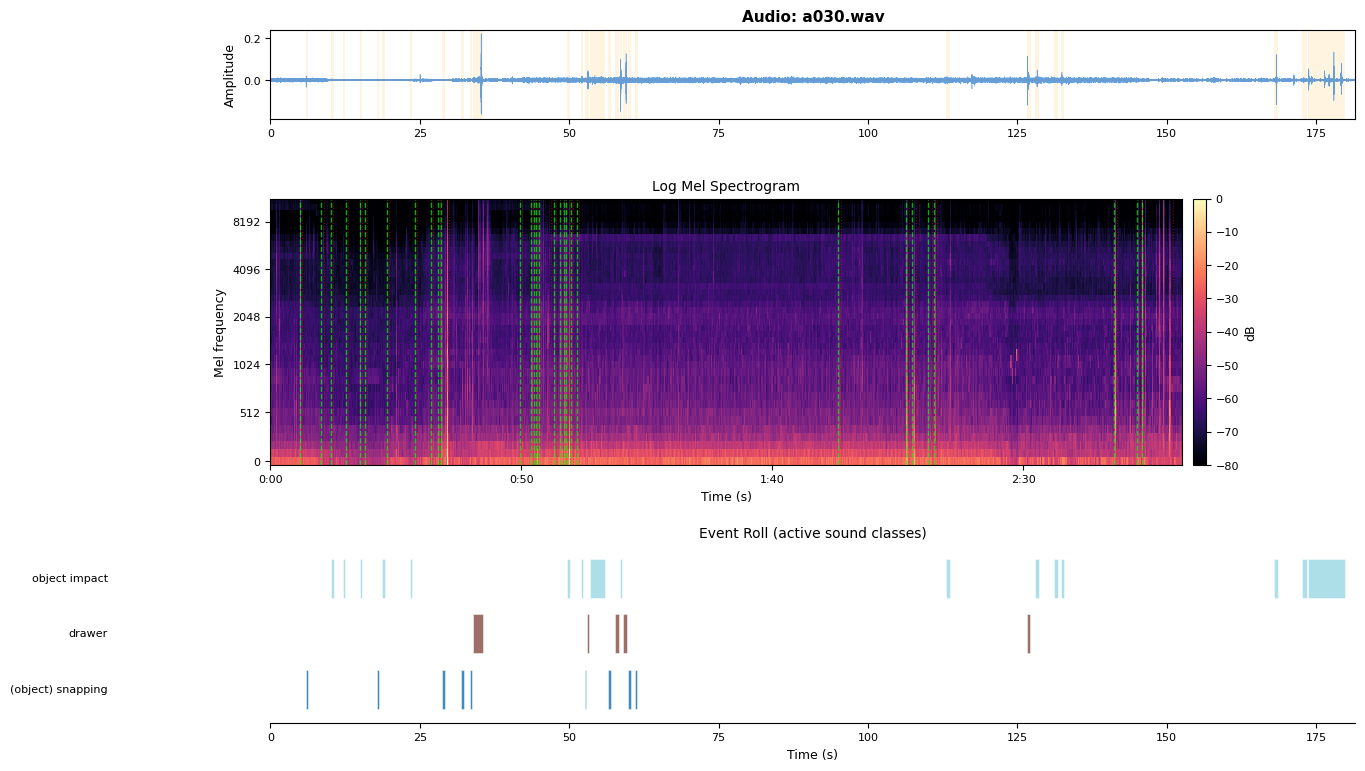

✅ Saved log_mel_visualization.png

Feature shape : (40, 7820)
  (40 time frames × 7820 mel bins)
  Duration     : 0.93 seconds
  dB range     : -80.0 to 0.0 dB


In [ ]:
# ─────────────────────────────────────────────────────────────────
# RUN: visualize a single file
# ─────────────────────────────────────────────────────────────────

# Pick any file from your dataset
sample_file = audio_files[0]
print(f"Visualizing: {sample_file}")

log_mel = visualize_log_mel(
    audio_path     = sample_file,
    annotations_df = annotations     # pass None to skip event roll
)

print(f"\nFeature shape : {log_mel.shape}")
print(f"  ({log_mel.shape[0]} time frames × {log_mel.shape[1]} mel bins)")
print(f"  Duration     : {log_mel.shape[0] * HOP_LENGTH / SR:.2f} seconds")
print(f"  dB range     : {log_mel.min():.1f} to {log_mel.max():.1f} dB")

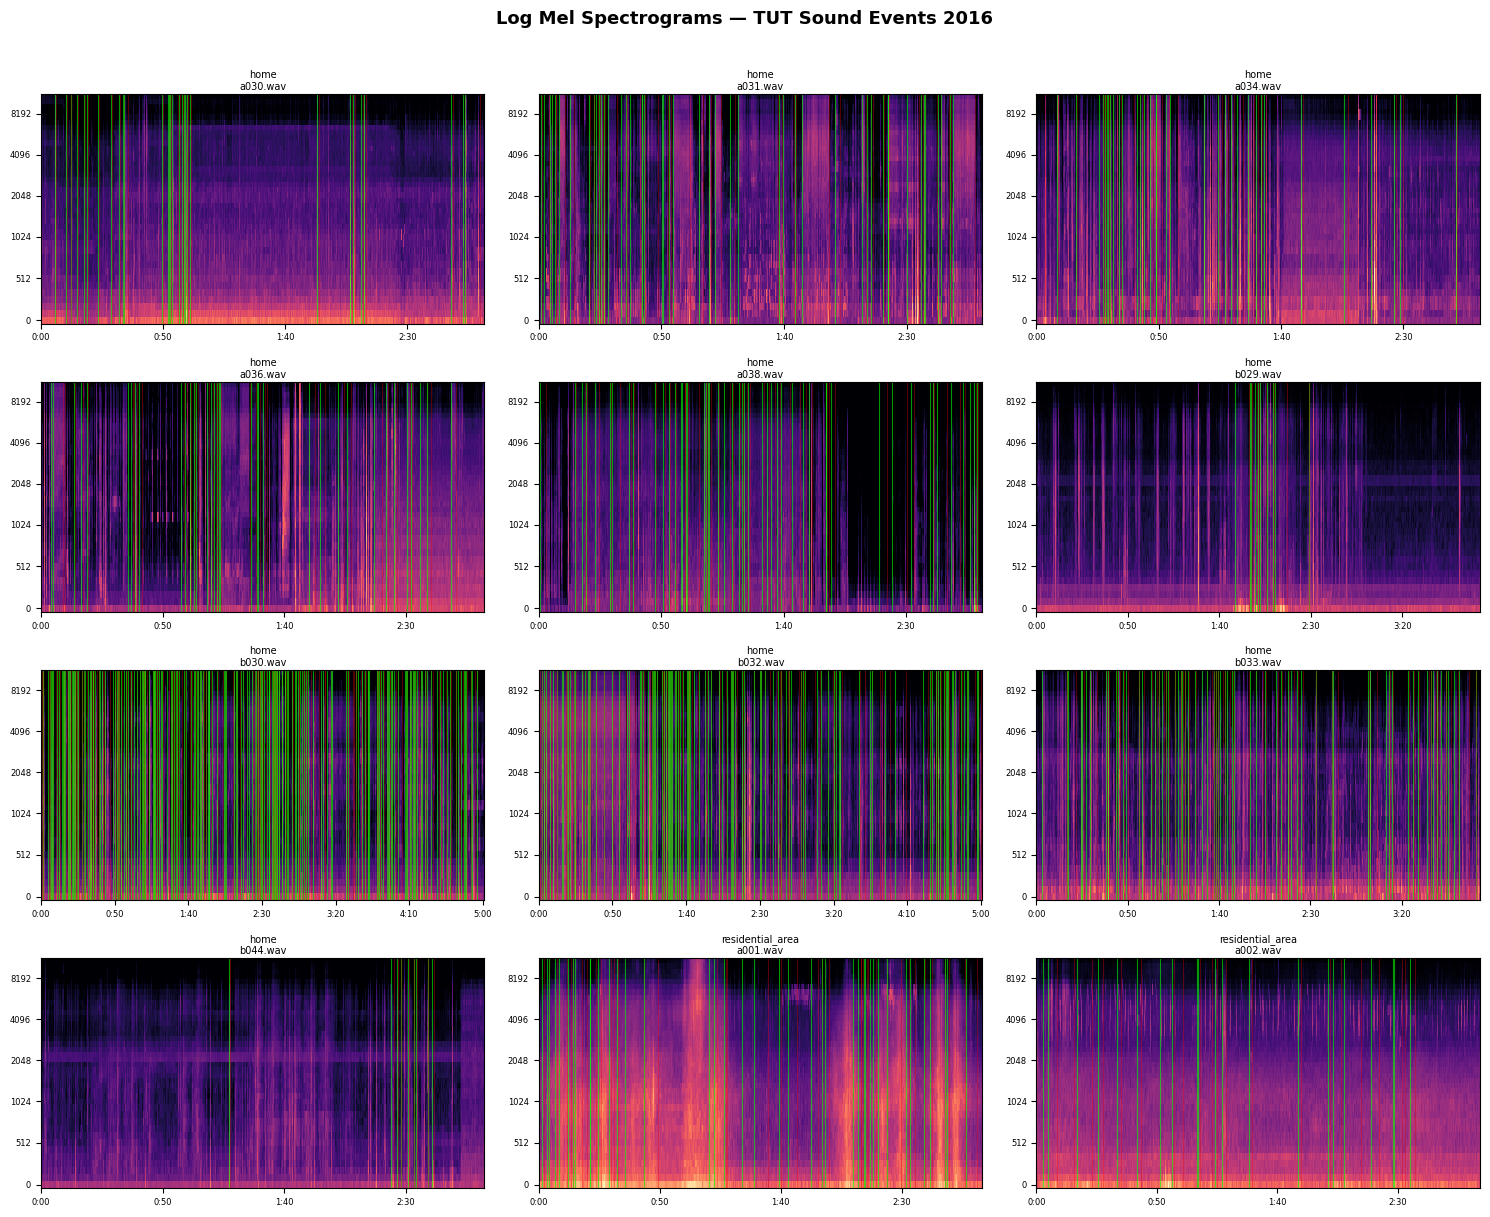

✅ Saved all_spectrograms_overview.png


In [ ]:
# ─────────────────────────────────────────────────────────────────
# BONUS: Visualize all files in a grid overview
# ─────────────────────────────────────────────────────────────────

def visualize_all_files(audio_files, annotations_df,
                        max_files=12, n_cols=3):
    """
    Grid view of log mel spectrograms for multiple files.
    Useful for checking data quality across the dataset.
    """
    files_to_plot = audio_files[:max_files]
    n_cols        = min(n_cols, len(files_to_plot))
    n_rows        = int(np.ceil(len(files_to_plot) / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 3 * n_rows)
    )
    axes = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle('Log Mel Spectrograms — TUT Sound Events 2016',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, audio_path in enumerate(files_to_plot):
        row, col = divmod(i, n_cols)
        ax       = axes[row, col]

        # Load and extract
        y, _      = librosa.load(audio_path, sr=SR, mono=True)
        mel       = librosa.feature.melspectrogram(
                        y=y, sr=SR, n_fft=N_FFT,
                        hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel   = librosa.power_to_db(mel, ref=np.max)
        filename  = os.path.basename(audio_path)
        scene     = os.path.basename(os.path.dirname(audio_path))

        # Display
        librosa.display.specshow(
            log_mel, sr=SR,
            hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel',
            ax=ax, cmap='magma'
        )

        # Overlay event onset lines
        file_anns = annotations_df[
            annotations_df['filename'] == filename
        ]
        for _, row_ann in file_anns.iterrows():
            ax.axvline(row_ann['onset'],  color='lime',
                       linewidth=0.8, alpha=0.6)
            ax.axvline(row_ann['offset'], color='red',
                       linewidth=0.6, alpha=0.4)

        ax.set_title(f'{scene}\n{filename}', fontsize=7, pad=3)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(labelsize=6)

    # Hide unused axes
    for i in range(len(files_to_plot), n_rows * n_cols):
        row, col = divmod(i, n_cols)
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.savefig('all_spectrograms_overview.png',
                dpi=130, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("✅ Saved all_spectrograms_overview.png")

# Run grid overview
visualize_all_files(audio_files, annotations, max_files=12, n_cols=3)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 6: SEGMENT ALL FILES  →  X and y arrays
# ─────────────────────────────────────────────────────────────────
def segment_file(log_mel, event_roll, n_frames=N_FRAMES, hop=None):
    """
    Slice (T, F) feature and (T, C) label into fixed-length segments.
    hop=None means non-overlapping; hop=n_frames//2 gives 50% overlap.
    """
    if hop is None:
        hop = n_frames  # non-overlapping by default

    T = min(log_mel.shape[0], event_roll.shape[0])
    log_mel    = log_mel[:T]
    event_roll = event_roll[:T]

    X_segs, y_segs = [], []
    for start in range(0, T - n_frames + 1, hop):
        end = start + n_frames
        X_segs.append(log_mel[start:end])       # (N_FRAMES, N_MELS)
        y_segs.append(event_roll[start:end])     # (N_FRAMES, N_CLASSES)

    return X_segs, y_segs


# ── Process every audio file ──────────────────────────────────────
all_X, all_y = [], []

for audio_path in audio_files:
    filename = os.path.basename(audio_path)

    # Skip files with no annotations
    if filename not in annotations['filename'].values:
        print(f"⚠️  No annotations for {filename}, skipping")
        continue

    # Extract features
    log_mel = extract_log_mel(audio_path)          # (T, 40)
    T       = log_mel.shape[0]

    # Build label matrix
    event_roll = build_event_roll(
                     annotations, audio_path, n_frames=T)  # (T, 18)

    # Slice into segments
    X_segs, y_segs = segment_file(log_mel, event_roll,
                                  n_frames=N_FRAMES,
                                  hop=N_FRAMES // 2)       # 50% overlap

    all_X.extend(X_segs)
    all_y.extend(y_segs)

    print(f"  {filename}: {T} frames → {len(X_segs)} segments")

# Stack into numpy arrays
X = np.array(all_X, dtype=np.float32)   # (N_segments, 128, 40)
y = np.array(all_y, dtype=np.float32)   # (N_segments, 128, 18)

print(f"\n✅ X shape : {X.shape}")
print(f"✅ y shape : {y.shape}")

  a030.wav: 7820 frames → 121 segments
  a031.wav: 7781 frames → 120 segments
  a034.wav: 7807 frames → 120 segments
  a036.wav: 7846 frames → 121 segments
  a038.wav: 7802 frames → 120 segments
  b029.wav: 10441 frames → 162 segments
  b030.wav: 12967 frames → 201 segments
  b032.wav: 12958 frames → 201 segments
  b033.wav: 10465 frames → 162 segments
  b044.wav: 7846 frames → 121 segments
  a001.wav: 7893 frames → 122 segments
  a002.wav: 7929 frames → 122 segments
  a003.wav: 10679 frames → 165 segments
  a010.wav: 9086 frames → 140 segments
  a011.wav: 9299 frames → 144 segments
  a012.wav: 9264 frames → 143 segments
  a013.wav: 9682 frames → 150 segments
  b002.wav: 8495 frames → 131 segments
  b003.wav: 10135 frames → 157 segments
  b004.wav: 6728 frames → 104 segments
  b007.wav: 9349 frames → 145 segments
  b009.wav: 10009 frames → 155 segments

✅ X shape : (3127, 128, 40)
✅ y shape : (3127, 128, 17)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 7: NORMALIZE FEATURES  (zero mean, unit variance)
# Fit ONLY on training data to avoid data leakage
# ─────────────────────────────────────────────────────────────────
# First split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Compute mean/std on training set only
mean = X_train.mean()
std  = X_train.std() + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_val   : {X_val.shape}")
print(f"✅ y_train : {y_train.shape}")
print(f"✅ y_val   : {y_val.shape}")

✅ X_train : (2501, 128, 40)
✅ X_val   : (626, 128, 40)
✅ y_train : (2501, 128, 17)
✅ y_val   : (626, 128, 17)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ─────────────────────────────────────────────────────────────────
# CUSTOM METRIC: Flatten (batch, time, classes) → (batch*time, classes)
# before passing to AUC so rank matches what Keras expects
# ─────────────────────────────────────────────────────────────────
class FlatAUC(tf.keras.metrics.AUC):
    """
    Wraps standard AUC but reshapes 3D SED output
    (batch, time_frames, n_classes) → (batch*time_frames, n_classes)
    before computing the metric.
    """
    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true, y_pred shape: (batch, T, C)
        shape    = tf.shape(y_pred)
        batch_T  = shape[0] * shape[1]          # merge batch and time
        n_cls    = shape[2]

        y_true_flat = tf.reshape(y_true, [batch_T, n_cls])
        y_pred_flat = tf.reshape(y_pred, [batch_T, n_cls])

        super().update_state(y_true_flat, y_pred_flat, sample_weight)

In [ ]:
class FlatF1Score(tf.keras.metrics.Metric):
    """
    Frame-level macro F1 score across all classes.
    Flattens (batch, time, classes) → (batch*time, classes) first.
    """
    def __init__(self, threshold=0.5, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name='tp', initializer='zeros')
        self.fp = self.add_weight(name='fp', initializer='zeros')
        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        shape       = tf.shape(y_pred)
        batch_T     = shape[0] * shape[1]
        n_cls       = shape[2]

        y_true_flat = tf.reshape(y_true, [batch_T, n_cls])
        y_pred_flat = tf.cast(
                          tf.reshape(y_pred, [batch_T, n_cls]) >= self.threshold,
                          tf.float32)

        self.tp.assign_add(tf.reduce_sum(y_true_flat * y_pred_flat))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_flat) * y_pred_flat))
        self.fn.assign_add(tf.reduce_sum(y_true_flat * (1 - y_pred_flat)))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-8)
        recall    = self.tp / (self.tp + self.fn + 1e-8)
        return 2 * precision * recall / (precision + recall + 1e-8)

    def reset_state(self):
        self.tp.assign(0.)
        self.fp.assign(0.)
        self.fn.assign(0.)

In [ ]:
# ── Rebuild model with correct N_CLASSES ─────────────────────────
def build_crnn(n_frames=N_FRAMES, n_mels=N_MELS, n_classes=N_CLASSES):

    inputs = tf.keras.Input(shape=(n_frames, n_mels))
    x = layers.Reshape((n_frames, n_mels, 1))(inputs)

    # Conv Block 1
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(1, 5))(x)           # freq: 40→8
    x = layers.Dropout(0.3)(x)

    # Conv Block 2
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(1, 2))(x)           # freq: 8→4
    x = layers.Dropout(0.3)(x)

    # Conv Block 3
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(1, 2))(x)           # freq: 4→2
    x = layers.Dropout(0.3)(x)

    # Reshape for RNN
    _, T, F_red, C = x.shape
    x = layers.Reshape((n_frames, F_red * C))(x)

    # Bidirectional GRU
    x = layers.Bidirectional(
            layers.GRU(32, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(
            layers.GRU(32, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)

    # Output: (batch, time, n_classes)
    x = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x)
    outputs = layers.TimeDistributed(
                  layers.Dense(n_classes, activation='sigmoid'))(x)

    return models.Model(inputs=inputs, outputs=outputs)


# ── Rebuild with correct class count ─────────────────────────────
tf.keras.backend.clear_session()   # clear any old graph
model = build_crnn(n_classes=N_CLASSES)

# ── Compile with fixed metrics ────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        FlatAUC(multi_label=True, name='auc'),
        FlatF1Score(threshold=0.5, name='f1_score')
    ]
)

model.summary()

# ── Verify shapes match before training ──────────────────────────
print(f"\nShape checks:")
print(f"  X_train : {X_train.shape}   expected (N, {N_FRAMES}, {N_MELS})")
print(f"  y_train : {y_train.shape}   expected (N, {N_FRAMES}, {N_CLASSES})")
print(f"  X_val   : {X_val.shape}")
print(f"  y_val   : {y_val.shape}")

# Check output shape with a dummy batch
dummy_out = model(X_train[:2])
print(f"  Model output shape: {dummy_out.shape}  expected (2, {N_FRAMES}, {N_CLASSES})")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 40, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 40, 128)   │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 40, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 40, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 8, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 8, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 8, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 8, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 8, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 4, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 4, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 4, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 4, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 4, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 2, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 2, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 64)        │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128, 64)        │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 128, 32)        │         2,080 │
│ (TimeDistributed)               │                        │             

 Total params: 375,121 (1.43 MB)

 Trainable params: 374,353 (1.43 MB)

 Non-trainable params: 768 (3.00 KB)


Shape checks:
  X_train : (2501, 128, 40)   expected (N, 128, 40)
  y_train : (2501, 128, 17)   expected (N, 128, 17)
  X_val   : (626, 128, 40)
  y_val   : (626, 128, 17)
  Model output shape: (2, 128, 17)  expected (2, 128, 17)


In [ ]:
# Run this before anything else to confirm true class count
print(f"Actual number of classes: {len(ALL_CLASSES)}")
print(f"Class list:\n")
for i, c in enumerate(ALL_CLASSES):
    print(f"  {i:2d}: {c}")

Actual number of classes: 17
Class list:

   0: (object) banging
   1: (object) rustling
   2: (object) snapping
   3: bird singing
   4: car passing by
   5: children shouting
   6: cupboard
   7: cutlery
   8: dishes
   9: drawer
  10: glass jingling
  11: object impact
  12: people speaking
  13: people walking
  14: washing dishes
  15: water tap running
  16: wind blowing


In [ ]:
# Update this to match what printed above
N_CLASSES = len(ALL_CLASSES)   # use actual count, not hardcoded 18
print(f"N_CLASSES set to: {N_CLASSES}")

N_CLASSES set to: 17


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_sed_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.5217 - f1_score: 0.0885 - loss: 0.3756
Epoch 1: val_loss improved from None to 0.14207, saving model to best_sed_model.keras

Epoch 1: finished saving model to best_sed_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - auc: 0.5407 - f1_score: 0.0836 - loss: 0.2417 - val_auc: 0.6407 - val_f1_score: 0.0000e+00 - val_loss: 0.1421 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.6335 - f1_score: 0.1493 - loss: 0.1317
Epoch 2: val_loss improved from 0.14207 to 0.14024, saving model to best_sed_model.keras

Epoch 2: finished saving model to best_sed_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - auc: 0.6525 - f1_score: 0.1750 - loss: 0.1270 - val_auc: 0.7017 - val_f1_score: 0.0000e+00 - val_loss: 0.1402 - learning_rate: 0.0010
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.7064 - f1_score: 0.2749 - loss: 0.1169
Epoch 3: val_loss improved from 0.14024 to 0.12073, saving model to

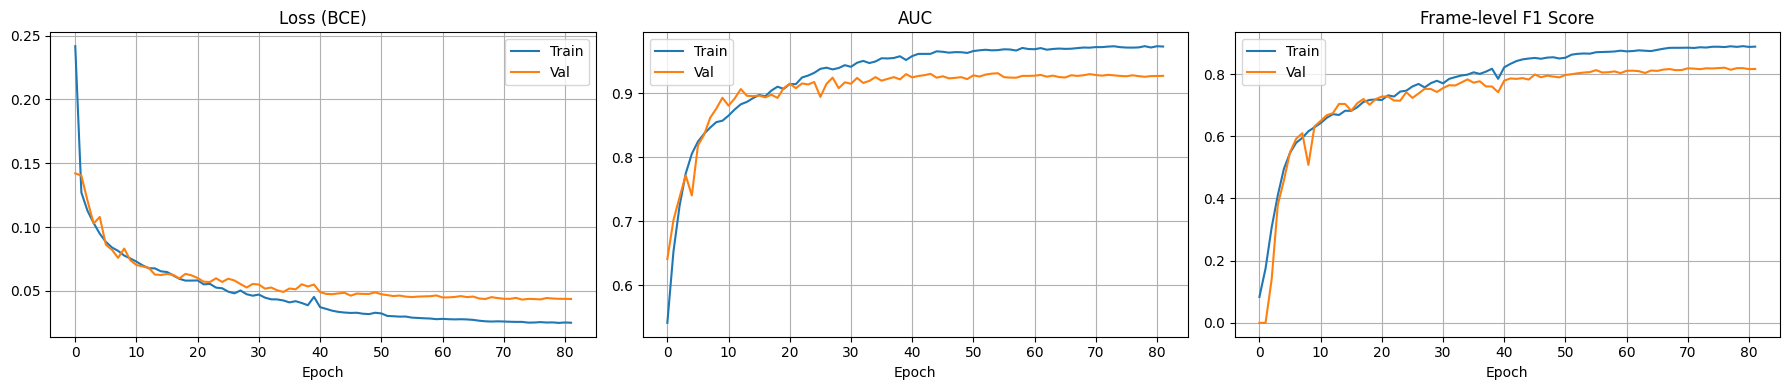

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (BCE)')
axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

# AUC
axes[1].plot(history.history['auc'],     label='Train')
axes[1].plot(history.history['val_auc'], label='Val')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

# F1
axes[2].plot(history.history['f1_score'],     label='Train')
axes[2].plot(history.history['val_f1_score'], label='Val')
axes[2].set_title('Frame-level F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

THRESHOLD = 0.5

# Predict on validation set
y_pred_prob = model.predict(X_val)                        # (N, 128, N_CLASSES)
y_pred      = (y_pred_prob >= THRESHOLD).astype(int)

# Flatten time dimension for evaluation
y_true_flat = y_val.reshape(-1, N_CLASSES)                # (N*128, N_CLASSES)
y_pred_flat = y_pred.reshape(-1, N_CLASSES)

# ── Per-class report ──────────────────────────────────────────────
print("=" * 65)
print("PER-CLASS PERFORMANCE (segment-based, frame-level)")
print("=" * 65)
report = classification_report(
    y_true_flat, y_pred_flat,
    target_names=ALL_CLASSES,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).T.round(3)
print(report_df)

# ── Class balance check ───────────────────────────────────────────
print("\n" + "=" * 65)
print("CLASS BALANCE (% of frames where class is active)")
print("=" * 65)
class_freq = y_true_flat.mean(axis=0)
for i, (cls, freq) in enumerate(zip(ALL_CLASSES, class_freq)):
    bar = "█" * int(freq * 50)
    print(f"  {i:2d}. {cls:<35} {freq*100:5.1f}%  {bar}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 730ms/step
PER-CLASS PERFORMANCE (segment-based, frame-level)
                   precision  recall  f1-score  support
(object) banging       0.000   0.000     0.000    122.0
(object) rustling      0.792   0.879     0.833   2308.0
(object) snapping      0.000   0.000     0.000    386.0
bird singing           0.918   0.835     0.874  15908.0
car passing by         0.897   0.847     0.872   9537.0
children shouting      0.729   0.472     0.573    741.0
cupboard               0.000   0.000     0.000    385.0
cutlery                0.813   0.566     0.667    553.0
dishes                 0.690   0.762     0.724   1954.0
drawer                 0.000   0.000     0.000    288.0
glass jingling         0.682   0.340     0.454    359.0
object impact          0.524   0.624     0.570   3324.0
people speaking        0.837   0.925     0.879   5875.0
people walking         0.709   0.672     0.690   4186.0
washing dishes         0.894   0.937     0.915   4559.0
water tap r

Segments with active events: 480

Segment 0:


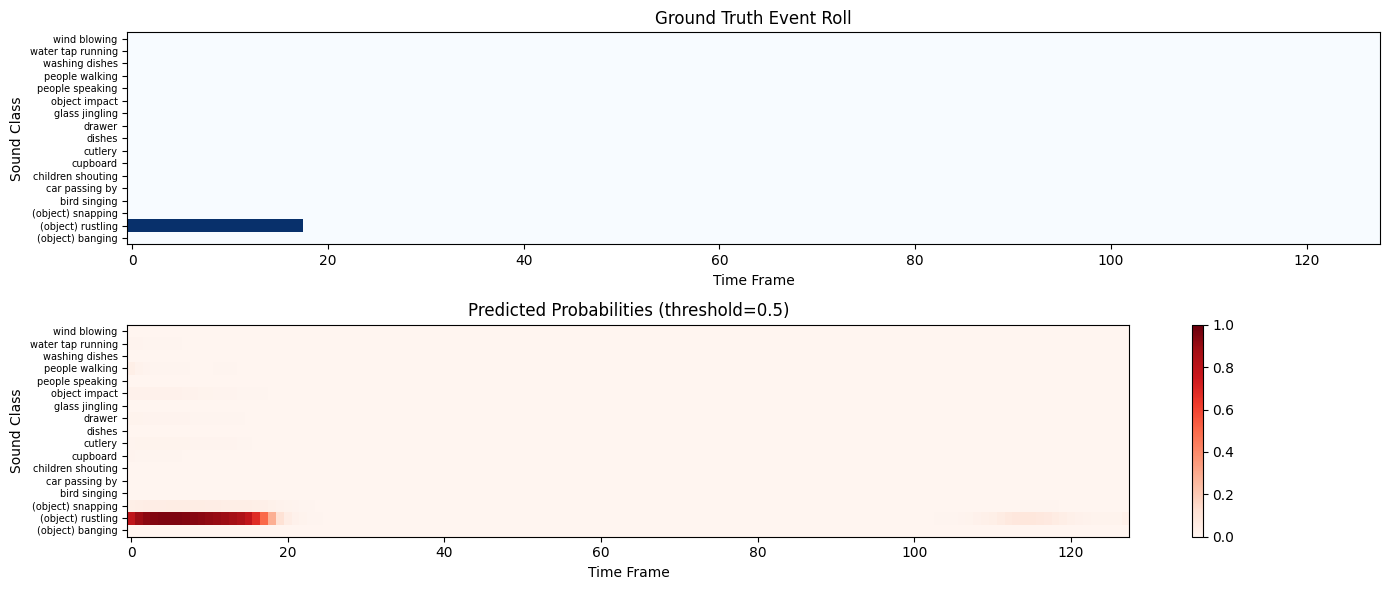


Segment 2:


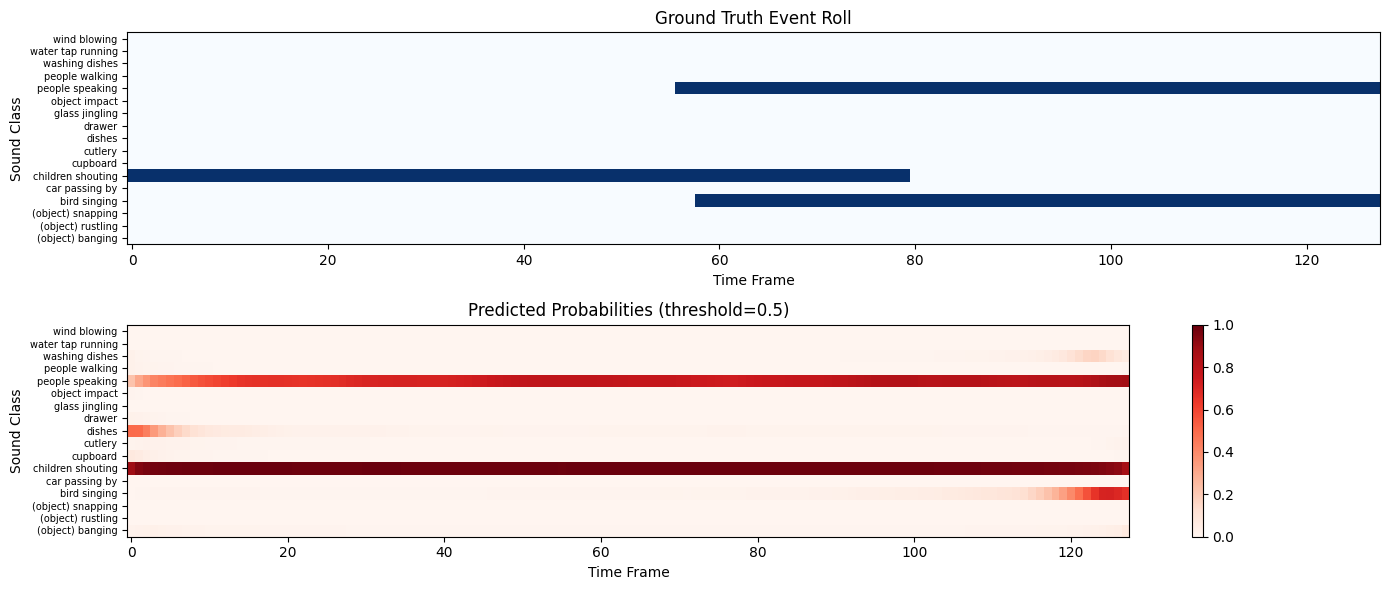


Segment 3:


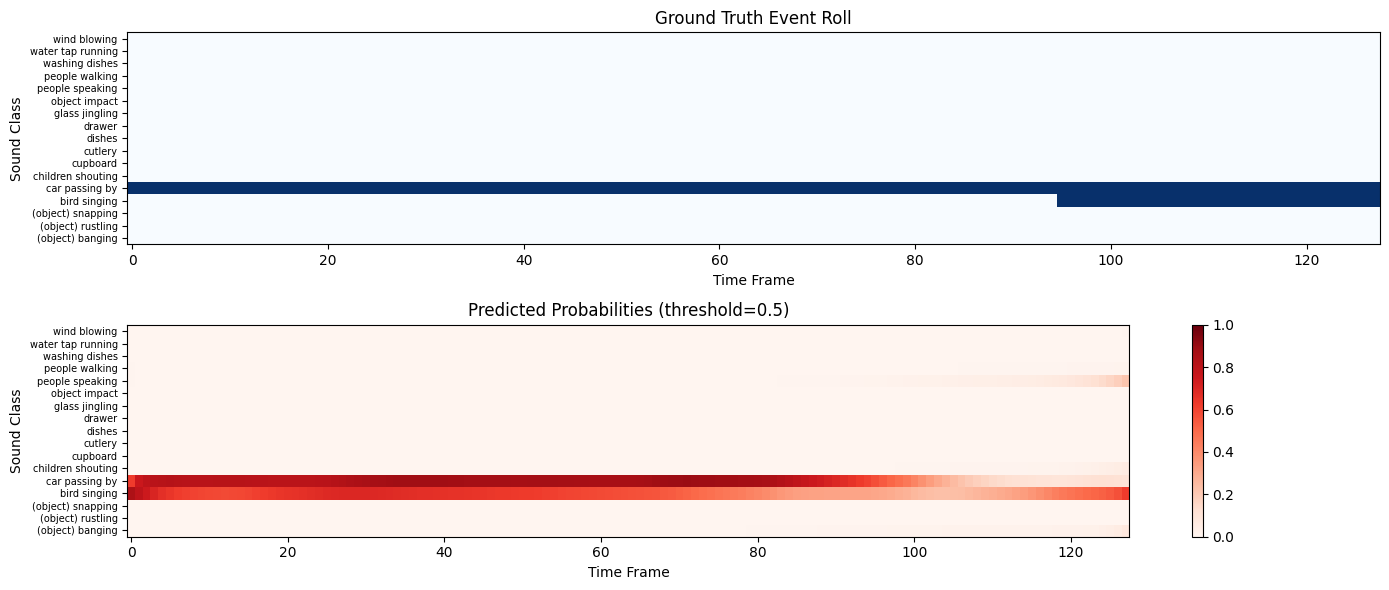

In [ ]:
def plot_predictions(y_true, y_pred_prob, sample_idx=0,
                     threshold=0.5, class_names=ALL_CLASSES):
    """
    Show ground truth event roll vs predicted probabilities
    for one validation segment.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))

    # Ground truth
    axes[0].imshow(y_true[sample_idx].T,
                   aspect='auto', origin='lower',
                   cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('Ground Truth Event Roll')
    axes[0].set_xlabel('Time Frame')
    axes[0].set_ylabel('Sound Class')
    axes[0].set_yticks(range(len(class_names)))
    axes[0].set_yticklabels(class_names, fontsize=7)

    # Predicted probabilities
    im = axes[1].imshow(y_pred_prob[sample_idx].T,
                        aspect='auto', origin='lower',
                        cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title(f'Predicted Probabilities (threshold={threshold})')
    axes[1].set_xlabel('Time Frame')
    axes[1].set_ylabel('Sound Class')
    axes[1].set_yticks(range(len(class_names)))
    axes[1].set_yticklabels(class_names, fontsize=7)
    plt.colorbar(im, ax=axes[1])

    plt.tight_layout()
    plt.show()

# Find a segment that has at least some active events
active_segments = np.where(y_val.sum(axis=(1,2)) > 0)[0]
print(f"Segments with active events: {len(active_segments)}")

# Plot a few examples
for idx in active_segments[:3]:
    print(f"\nSegment {idx}:")
    plot_predictions(y_val, y_pred_prob, sample_idx=idx)

In [ ]:
from sklearn.metrics import f1_score

print("=" * 55)
print("OPTIMAL THRESHOLD PER CLASS")
print("=" * 55)

thresholds  = np.arange(0.1, 0.9, 0.05)
best_thresh = {}

for cls_idx, cls_name in enumerate(ALL_CLASSES):
    true_cls = y_true_flat[:, cls_idx]

    # Skip classes with no positive examples
    if true_cls.sum() == 0:
        print(f"  {cls_name:<35} — no positive examples, skipping")
        best_thresh[cls_name] = 0.5
        continue

    best_f1, best_t = 0, 0.5
    for t in thresholds:
        pred_cls = (y_pred_prob.reshape(-1, N_CLASSES)[:, cls_idx] >= t).astype(int)
        f1 = f1_score(true_cls, pred_cls, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    best_thresh[cls_name] = best_t
    bar = "█" * int(best_f1 * 30)
    print(f"  {cls_name:<35} thresh={best_t:.2f}  F1={best_f1:.3f}  {bar}")

# Apply per-class thresholds
pred_prob_flat = y_pred_prob.reshape(-1, N_CLASSES)
y_pred_optimal = np.zeros_like(pred_prob_flat)
for cls_idx, cls_name in enumerate(ALL_CLASSES):
    y_pred_optimal[:, cls_idx] = (
        pred_prob_flat[:, cls_idx] >= best_thresh[cls_name]
    ).astype(int)

# Overall F1 with optimal thresholds
macro_f1 = f1_score(y_true_flat, y_pred_optimal,
                    average='macro', zero_division=0)
print(f"\nMacro F1 with optimal thresholds : {macro_f1:.4f}")
print(f"Macro F1 with fixed 0.5 threshold : "
      f"{f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0):.4f}")

OPTIMAL THRESHOLD PER CLASS
  (object) banging                    thresh=0.50  F1=0.000  
  (object) rustling                   thresh=0.70  F1=0.836  █████████████████████████
  (object) snapping                   thresh=0.10  F1=0.049  █
  bird singing                        thresh=0.30  F1=0.881  ██████████████████████████
  car passing by                      thresh=0.15  F1=0.876  ██████████████████████████
  children shouting                   thresh=0.15  F1=0.667  ████████████████████
  cupboard                            thresh=0.10  F1=0.277  ████████
  cutlery                             thresh=0.40  F1=0.684  ████████████████████
  dishes                              thresh=0.55  F1=0.727  █████████████████████
  drawer                              thresh=0.10  F1=0.220  ██████
  glass jingling                      thresh=0.35  F1=0.522  ███████████████
  object impact                       thresh=0.40  F1=0.579  █████████████████
  people speaking                     thres